In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd 
import matplotlib.pyplot as plt
import os

dataset_path = os.listdir('dataset test')

print (dataset_path)  #what kinds of classes are in this dataset

print("Types of classes labels found: ", len(dataset_path))

['earphone', 'headphone', 'phones']
Types of classes labels found:  3


In [2]:
class_labels = []

for item in dataset_path:
 # Get all the file names
 all_classes = os.listdir('dataset test'+ '/' +item)
 #print(all_classes)

 # Add them to the list
 for room in all_classes:
    class_labels.append((item, str('dataset_path' + '/' +item) + '/' + room))
    #print(class_labels[:5])

In [3]:
# Build a dataframe        
df = pd.DataFrame(data=class_labels, columns=['Labels', 'image'])
print(df.head())
print(df.tail())

     Labels                                              image
0  earphone  dataset_path/earphone/0008474-single-earphone-...
1  earphone  dataset_path/earphone/0038219-portronics-earph...
2  earphone                       dataset_path/earphone/21.png
3  earphone                       dataset_path/earphone/22.png
4  earphone  dataset_path/earphone/6fd41ea92ccf089aa1b54987...
    Labels                                              image
43  phones            dataset_path/phones/smartphone1 (2).jpg
44  phones                dataset_path/phones/smartphone3.jpg
45  phones  dataset_path/phones/smartphones-2012-latest-sa...
46  phones          dataset_path/phones/smartphone_x1 (1).jpg
47  phones               dataset_path/phones/__smartphone.jpg


In [4]:
# Let's check how many samples for each category are present
print("Total number of images in the dataset: ", len(df))

label_count = df['Labels'].value_counts()
print(label_count)

Total number of images in the dataset:  48
phones       16
headphone    16
earphone     16
Name: Labels, dtype: int64


In [5]:
import cv2
path = 'dataset test/'
dataset_path = os.listdir('dataset test')

im_size = 224

images = []
labels = []

for i in dataset_path:
    data_path = path + str(i)  
    filenames = [i for i in os.listdir(data_path) ]
   
    for f in filenames:
        img = cv2.imread(data_path + '/' + f)
        img = cv2.resize(img, (im_size, im_size))
        images.append(img)
        labels.append(i)

In [6]:
#This model takes input images of shape (224, 224, 3), and the input data should range [0, 255]. 

images = np.array(images)

images = images.astype('float32') / 48.0                 #float 64
images.shape

(48, 224, 224, 3)

In [7]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
y=df['Labels'].values
print(y)

y_labelencoder = LabelEncoder ()
y = y_labelencoder.fit_transform (y)
print (y)

['earphone' 'earphone' 'earphone' 'earphone' 'earphone' 'earphone'
 'earphone' 'earphone' 'earphone' 'earphone' 'earphone' 'earphone'
 'earphone' 'earphone' 'earphone' 'earphone' 'headphone' 'headphone'
 'headphone' 'headphone' 'headphone' 'headphone' 'headphone' 'headphone'
 'headphone' 'headphone' 'headphone' 'headphone' 'headphone' 'headphone'
 'headphone' 'headphone' 'phones' 'phones' 'phones' 'phones' 'phones'
 'phones' 'phones' 'phones' 'phones' 'phones' 'phones' 'phones' 'phones'
 'phones' 'phones' 'phones']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2]


In [8]:

y=y.reshape(-1,1)

from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('my_ohe', OneHotEncoder(), [0])], remainder='passthrough')
Y = ct.fit_transform(y) #.toarray()
print(Y[:5])
print(Y[35:])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [9]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split


images, Y = shuffle(images, Y, random_state=1)


train_x, test_x, train_y, test_y = train_test_split(images, Y, test_size=0.05, random_state=415)

#inpect the shape of the training and testing.
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)

print(test_y.shape)



(45, 224, 224, 3)
(45, 3)
(3, 224, 224, 3)
(3, 3)


In [10]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0


NUM_CLASSES = 3
IMG_SIZE = 224
size = (IMG_SIZE, IMG_SIZE)


inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))


# Using model without transfer learning

outputs = EfficientNetB0(include_top=True, weights=None, classes=NUM_CLASSES)(inputs)

In [11]:
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"] )

model.summary()

hist = model.fit(train_x, train_y, validation_split=0.2, epochs=10, verbose=2)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 3)                4053414   
                                                                 
Total params: 4,053,414
Trainable params: 4,011,391
Non-trainable params: 42,023
_________________________________________________________________
Epoch 1/10
2/2 - 9s - loss: 5.3153 - accuracy: 0.4167 - val_loss: 1.1137 - val_accuracy: 0.3333 - 9s/epoch - 4s/step
Epoch 2/10
2/2 - 3s - loss: 8.6215 - accuracy: 0.3333 - val_loss: 1.1363 - val_accuracy: 0.4444 - 3s/epoch - 2s/step
Epoch 3/10
2/2 - 3s - loss: 7.1051 - accuracy: 0.3611 - val_loss: 1.2426 - val_accuracy: 0.2222 - 3s/epoch - 2s/step
Epoch 4/10
2/2 - 3s - loss: 1.7936 - accuracy: 0.5000 - val_loss: 1.1779 - val_accuracy: 0.

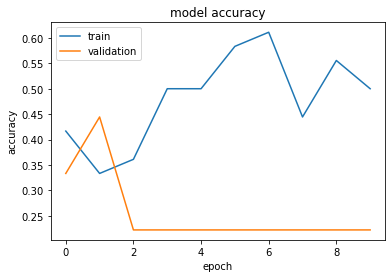

In [12]:
import matplotlib.pyplot as plt


def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()


plot_hist(hist)

In [13]:
preds = model.evaluate(test_x, test_y)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

1/1 [==============================] - 0s 72ms/step - loss: 0.7890 - accuracy: 0.6667
Loss = 0.7889881730079651
Test Accuracy = 0.6666666865348816


Input image shape: (1, 224, 224, 3)


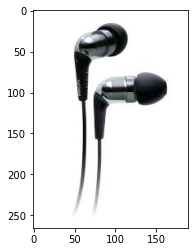

In [14]:
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input


img_path = '22.png'

#img = image.load_img(img_path, target_size=(224, 224))
#x = img.img_to_array(img)

img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

In [15]:
preds=model.predict(x)
preds     # probabilities for being in each of the 3 classes

array([[0.13626638, 0.24338152, 0.6203521 ]], dtype=float32)

In [16]:
preds=model.predict(test_x)
preds     # probabilities for being in each of the 3 classes


array([[0.13590662, 0.24331297, 0.6207804 ],
       [0.13590844, 0.24331264, 0.6207789 ],
       [0.13590644, 0.24331293, 0.62078065]], dtype=float32)

In [17]:
from sklearn.metrics import confusion_matrix

y_pred=np.argmax(preds, axis=1)
y_test=np.argmax(test_y, axis=1)


#Generate the confusion matrix
cf_matrix = confusion_matrix(y_test,y_pred)

print(cf_matrix)

[[0 1]
 [0 2]]


In [18]:
# Cuda and cudnn is installed for this tensorflow version. So we can see GPU is enabled
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [19]:
%%timeit -n1 -r1 
with tf.device('/CPU:0'):
    cpu_performance =model.fit(train_x, train_y, epochs=10, verbose=2)
    cpu_performance

Epoch 1/10
2/2 - 3s - loss: 1.7825 - accuracy: 0.6000 - 3s/epoch - 2s/step
Epoch 2/10
2/2 - 4s - loss: 3.9643 - accuracy: 0.5778 - 4s/epoch - 2s/step
Epoch 3/10
2/2 - 4s - loss: 1.5971 - accuracy: 0.6444 - 4s/epoch - 2s/step
Epoch 4/10
2/2 - 4s - loss: 1.4203 - accuracy: 0.6000 - 4s/epoch - 2s/step
Epoch 5/10
2/2 - 4s - loss: 1.3949 - accuracy: 0.7111 - 4s/epoch - 2s/step
Epoch 6/10
2/2 - 4s - loss: 1.4422 - accuracy: 0.6667 - 4s/epoch - 2s/step
Epoch 7/10
2/2 - 4s - loss: 1.3663 - accuracy: 0.7111 - 4s/epoch - 2s/step
Epoch 8/10
2/2 - 3s - loss: 2.0800 - accuracy: 0.6889 - 3s/epoch - 2s/step
Epoch 9/10
2/2 - 3s - loss: 1.8375 - accuracy: 0.7333 - 3s/epoch - 2s/step
Epoch 10/10
2/2 - 4s - loss: 1.6226 - accuracy: 0.8222 - 4s/epoch - 2s/step
35.8 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [20]:
%%timeit -n1 -r1 
with tf.device('/GPU:0'):
    gpu_performance =model.fit(train_x, train_y, epochs=10, verbose=2)
    gpu_performance

Epoch 1/10
2/2 - 4s - loss: 0.8396 - accuracy: 0.8000 - 4s/epoch - 2s/step
Epoch 2/10
2/2 - 4s - loss: 0.2310 - accuracy: 0.9111 - 4s/epoch - 2s/step
Epoch 3/10
2/2 - 4s - loss: 0.2863 - accuracy: 0.9111 - 4s/epoch - 2s/step
Epoch 4/10
2/2 - 4s - loss: 1.1491 - accuracy: 0.8444 - 4s/epoch - 2s/step
Epoch 5/10
2/2 - 4s - loss: 1.0304 - accuracy: 0.8000 - 4s/epoch - 2s/step
Epoch 6/10
2/2 - 4s - loss: 0.3683 - accuracy: 0.8667 - 4s/epoch - 2s/step
Epoch 7/10
2/2 - 4s - loss: 0.1374 - accuracy: 0.9333 - 4s/epoch - 2s/step
Epoch 8/10
2/2 - 4s - loss: 0.5868 - accuracy: 0.8889 - 4s/epoch - 2s/step
Epoch 9/10
2/2 - 4s - loss: 0.1129 - accuracy: 0.9556 - 4s/epoch - 2s/step
Epoch 10/10
2/2 - 4s - loss: 0.2441 - accuracy: 0.9111 - 4s/epoch - 2s/step
36.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [21]:
#CPU completed the training in 7 min 53 Seconds and GPU did that training in 25.6 seconds);



In [22]:
efficientnet="hist.h5"
model.save(efficientnet)